In [1]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.feature_selection import SelectKBest, f_classif, VarianceThreshold
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree, export_text
import pandas as pd
import numpy as np
import warnings
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.preprocessing import LabelEncoder, PolynomialFeatures
from te2rules.explainer import ModelExplainer

In [2]:
df = pd.read_csv('../../results/metrics.csv')
print(f"Dataset shape: {df.shape}")
print(f"\nColumns: {list(df.columns)}")
print(f"\nTarget distribution:\n{df['is_high_risk'].value_counts()}")

Dataset shape: (4246, 49)

Columns: ['file_path', 'is_high_risk', 'nargs_fn_nargs', 'nargs_closure_nargs', 'nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_min', 'nargs_closure_nargs_min', 'nargs_fn_nargs_max', 'nargs_closure_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_min', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_sum', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_min', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_operands', 'halstead_volume', 'halstead_difficulty', 'halstead_level', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'loc_cloc', 'loc_lloc', 'loc_blank', 'mi_mi_original', 'mi_mi_sei', 'mi_mi_visual_studio', 'abc_assignments', 'abc_branches', 'abc_conditions', 'nom_functions', 'nom_closures', 'wmc_cyclomati

In [3]:
df['repo'] = df['file_path'].str.split('__').str[0]
print(f"Total unique repos: {df['repo'].nunique()}")
print("\nTop 10 repos by file count:")
print(df['repo'].value_counts().head(10))

df_with_repo = df.copy()

Total unique repos: 151

Top 10 repos by file count:
repo
OpenMD                 355
core                   191
Easy3D                 165
universal              156
FlowSieve              149
pyclustering           143
ERF                    142
Open-Infra-Platform    141
CADET-Core             129
gyselalibxx            119
Name: count, dtype: int64


In [4]:
target_col = 'is_high_risk'
exclude_cols = ['file_path', 'repo', target_col]

feature_cols = [col for col in df.columns if col not in exclude_cols]
print(f"\nNumber of features: {len(feature_cols)}")

df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

X = df[feature_cols].copy()
y = df[target_col].copy()

X = X.select_dtypes(include=[np.number])
print(f"Numeric features: {list(X.columns)}")

X = X.fillna(X.median())

le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))
print(f"\nTarget classes: {le.classes_}")
print(f"Encoded: {dict(zip(le.classes_, range(len(le.classes_))))}")


Number of features: 47
Numeric features: ['nargs_fn_nargs', 'nargs_closure_nargs', 'nargs_fn_nargs_sum', 'nargs_closure_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_closure_nargs_avg', 'nargs_fn_nargs_min', 'nargs_closure_nargs_min', 'nargs_fn_nargs_max', 'nargs_closure_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_min', 'nexits_exit_max', 'cognitive', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_sum', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_min', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_operands', 'halstead_volume', 'halstead_difficulty', 'halstead_level', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'loc_cloc', 'loc_lloc', 'loc_blank', 'mi_mi_original', 'mi_mi_sei', 'mi_mi_visual_studio', 'abc_assignments', 'abc_branches', 'abc_conditions', 'nom_functions', 'nom_closures', 'wmc_cyclomatic']

Target classes: ['

In [5]:
df_fe = df.copy()

df_fe['operator_operand_ratio'] = df_fe['halstead_operators'] / \
    (df_fe['halstead_operands'] + 1)
df_fe['sloc_per_function'] = df_fe['loc_sloc'] / (df_fe['nom_functions'] + 1)
df_fe['complexity_per_function'] = df_fe['wmc_cyclomatic'] / \
    (df_fe['nom_functions'] + 1)
df_fe['effort_per_volume'] = df_fe['halstead_effort'] / \
    (df_fe['halstead_volume'] + 1)
df_fe['avg_exit_per_fn'] = df_fe['nexits_exit_sum'] / \
    (df_fe['nom_functions'] + 1)
df_fe['cognitive_per_cyclomatic'] = df_fe['cognitive_sum'] / \
    (df_fe['cyclomatic_cyclomatic_sum'] + 1)

for col in ['halstead_volume', 'halstead_effort', 'loc_sloc', 'loc_ploc', 'halstead_operators', 'halstead_operands']:
    df_fe[f'{col}_log'] = np.log1p(df_fe[col])

numeric_df = df_fe.select_dtypes(include=[np.number])

target_col = 'is_high_risk'
exclude_cols = ['file_path', 'repo', target_col]

feature_cols = [col for col in df_fe.columns if col not in exclude_cols]
print(f"\nNumber of features after FE: {len(feature_cols)}")

df_fe.replace([np.inf, -np.inf], np.nan, inplace=True)
df_fe.dropna(inplace=True)

X = df_fe[feature_cols].copy()
X = X.select_dtypes(include=[np.number])
X = X.fillna(X.median())

y = df_fe[target_col].copy()
le = LabelEncoder()
y_encoded = le.fit_transform(y.astype(str))

print(f"Feature engineered dataset shape: {X.shape}")


Number of features after FE: 59
Feature engineered dataset shape: (4102, 59)


In [6]:

print("\n" + "="*60)
print("ENHANCED FEATURE ENGINEERING")
print("="*60)

X_enhanced = X.copy()

key_features = ['halstead_difficulty', 'halstead_effort', 'halstead_volume',
                'wmc_cyclomatic', 'cyclomatic_cyclomatic', 'loc_sloc',
                'nom_functions', 'cognitive']

existing_features = [f for f in key_features if f in X_enhanced.columns]
print(f"Found {len(existing_features)} key features for polynomial features")

poly = PolynomialFeatures(degree=2, include_bias=False, interaction_only=False)
X_key = X_enhanced[existing_features].copy()
poly_features = poly.fit_transform(X_key)
poly_feature_names = poly.get_feature_names_out(existing_features)

for i, name in enumerate(poly_feature_names):
    X_enhanced[f'poly_{name}'] = poly_features[:, i]

print(f"Added {len(poly_feature_names)} polynomial features")


X_enhanced.replace([np.inf, -np.inf], np.nan, inplace=True)
X_enhanced = X_enhanced.fillna(X_enhanced.median())

print(f"Enhanced feature count: {X_enhanced.shape[1]}")


ENHANCED FEATURE ENGINEERING
Found 8 key features for polynomial features
Added 44 polynomial features
Enhanced feature count: 103



FEATURE SELECTION
Dropping 48 highly correlated features (>0.90)


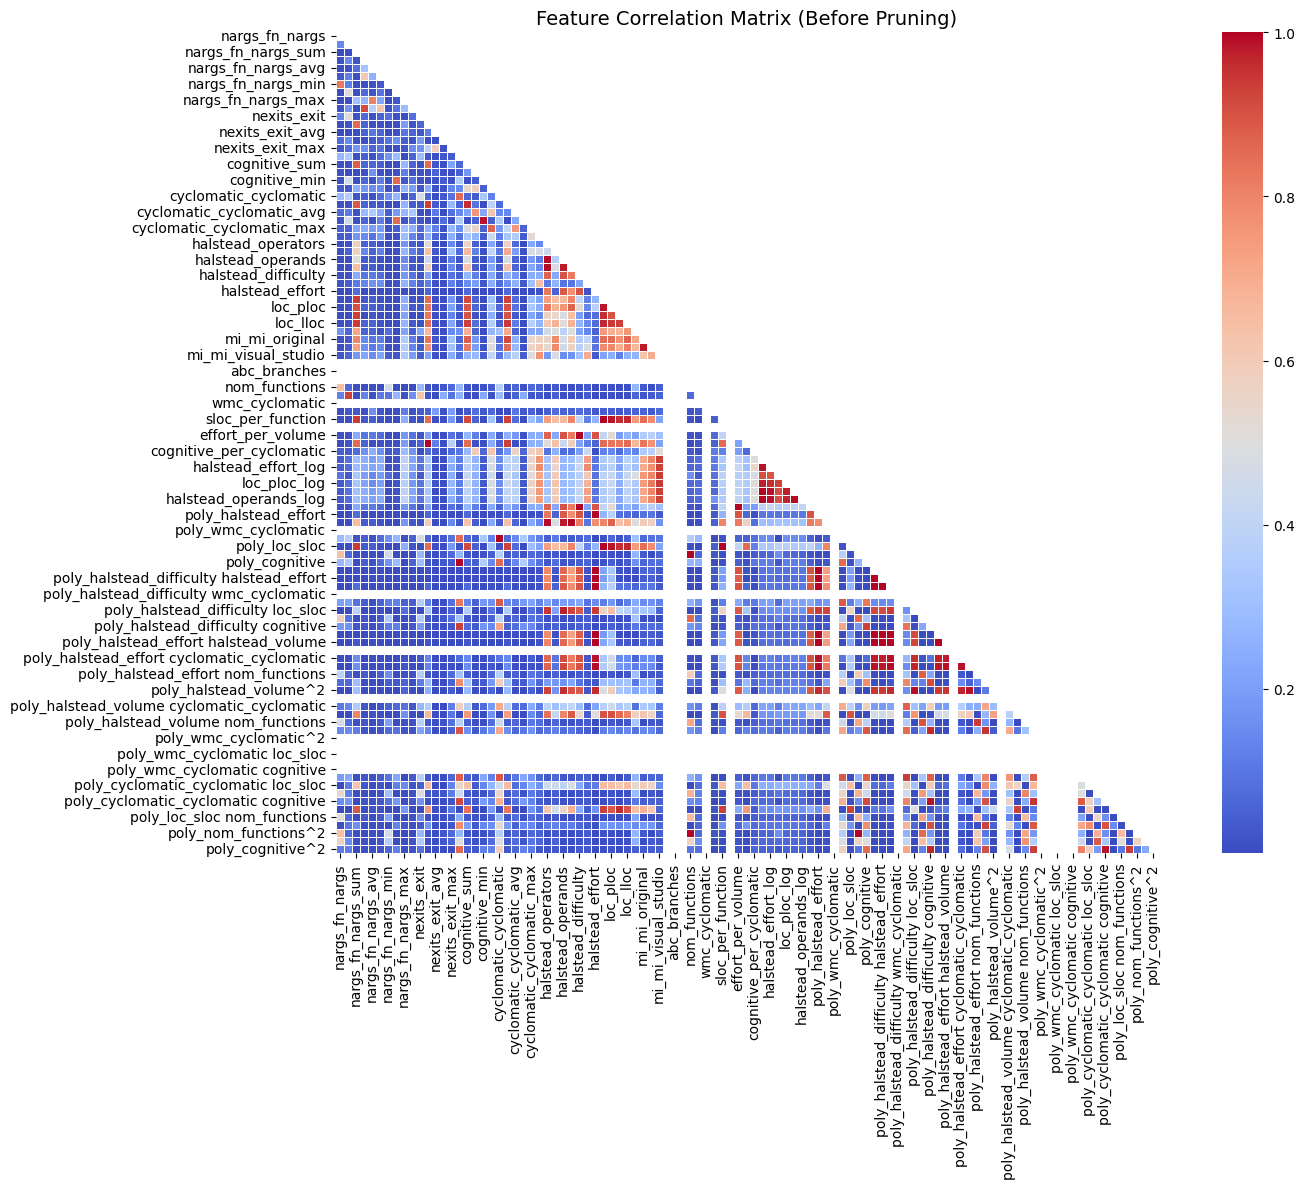


Highly correlated pairs (>0.90) being dropped (163 total):
  nargs_closure_nargs_sum <-> nargs_closure_nargs_max: 0.911
  nexits_exit_sum <-> cyclomatic_cyclomatic_sum: 0.932
  cognitive_sum <-> cyclomatic_cyclomatic_sum: 0.958
  cognitive_min <-> cyclomatic_cyclomatic_min: 0.985
  halstead_operators <-> halstead_operands: 0.993
  halstead_operators <-> halstead_volume: 0.994
  halstead_operands <-> halstead_volume: 0.978
  nargs_fn_nargs_sum <-> loc_sloc: 0.941
  cognitive_sum <-> loc_sloc: 0.917
  cyclomatic_cyclomatic_sum <-> loc_sloc: 0.928
  nargs_fn_nargs_sum <-> loc_ploc: 0.904
  cyclomatic_cyclomatic_sum <-> loc_ploc: 0.905
  loc_sloc <-> loc_ploc: 0.984
  nargs_fn_nargs_sum <-> loc_cloc: 0.934
  loc_sloc <-> loc_cloc: 0.957
Features after variance filtering: 39
Testing different k values for SelectKBest...
k=30: F1=0.7143


/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/feature_selection/_univariate_selection.py:782: UserWarning: k=50 is greater than n_features=39. All the features will be returned.
  warnings.warn(


k=50: F1=0.7124
k=39: F1=0.7124

Using best k=30
Final feature count after selection: 30
Selected features: ['nargs_fn_nargs_sum', 'nargs_fn_nargs_avg', 'nargs_fn_nargs_min', 'nargs_closure_nargs_min', 'nargs_fn_nargs_max', 'nexits_exit', 'nexits_exit_sum', 'nexits_exit_avg', 'nexits_exit_min', 'cognitive_sum', 'cognitive_avg', 'cognitive_min', 'cognitive_max', 'cyclomatic_cyclomatic', 'cyclomatic_cyclomatic_avg', 'cyclomatic_cyclomatic_max', 'halstead_u_operators', 'halstead_operators', 'halstead_u_operands', 'halstead_difficulty', 'loc_blank', 'mi_mi_visual_studio', 'operator_operand_ratio', 'cognitive_per_cyclomatic', 'poly_halstead_difficulty cyclomatic_cyclomatic', 'poly_halstead_difficulty nom_functions', 'poly_halstead_effort nom_functions', 'poly_halstead_volume cyclomatic_cyclomatic', 'poly_cyclomatic_cyclomatic loc_sloc', 'poly_loc_sloc nom_functions']


In [7]:

print("\n" + "="*60)
print("FEATURE SELECTION")
print("="*60)

corr_matrix = X_enhanced.corr().abs()
upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.90)]
print(f"Dropping {len(to_drop)} highly correlated features (>0.90)")
X_selected = X_enhanced.drop(columns=to_drop)

plt.figure(figsize=(16, 12))
corr_before = X_enhanced.corr().abs()
mask = np.triu(np.ones_like(corr_before, dtype=bool))
sns.heatmap(corr_before, mask=mask, cmap='coolwarm', center=0.5,
            annot=False, square=True, linewidths=0.5)
plt.title('Feature Correlation Matrix (Before Pruning)', fontsize=14)
plt.tight_layout()
plt.show()

high_corr_pairs = []
for col in upper.columns:
    for idx in upper.index:
        if upper.loc[idx, col] > 0.90:
            high_corr_pairs.append((idx, col, upper.loc[idx, col]))

print(f"\nHighly correlated pairs (>0.90) being dropped ({
      len(high_corr_pairs)} total):")
for f1, f2, corr in high_corr_pairs[:15]:
    print(f"  {f1} <-> {f2}: {corr:.3f}")

var_thresh = VarianceThreshold(threshold=0.01)
X_selected = pd.DataFrame(
    var_thresh.fit_transform(X_selected),
    columns=X_selected.columns[var_thresh.get_support()],
    index=X_selected.index
)
print(f"Features after variance filtering: {X_selected.shape[1]}")

X_selected.replace([np.inf, -np.inf], np.nan, inplace=True)
X_selected = X_selected.fillna(X_selected.median())
to_drop_nan = X_selected.columns[X_selected.isna().all()]
if len(to_drop_nan) > 0:
    X_selected = X_selected.drop(columns=to_drop_nan)
    print(f"Dropped {len(to_drop_nan)} all-NaN features")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
with warnings.catch_warnings():
    warnings.filterwarnings("ignore", category=RuntimeWarning)

    k_values = [30, 50, min(80, X_selected.shape[1])]
    best_k = 30
    best_score = 0

    print("Testing different k values for SelectKBest...")
    for k in k_values:
        selector_test = SelectKBest(f_classif, k=k)
        X_test = selector_test.fit_transform(X_selected, y_encoded)
        rf_test = RandomForestClassifier(
            n_estimators=100, random_state=42, n_jobs=-1)
        scores = cross_val_score(
            rf_test, X_test, y_encoded, cv=cv, scoring='f1')
        if scores.mean() > best_score:
            best_score = scores.mean()
            best_k = k
        print(f"k={k}: F1={scores.mean():.4f}")

    print(f"\nUsing best k={best_k}")
    selector = SelectKBest(f_classif, k=best_k)
    X_final = pd.DataFrame(
        selector.fit_transform(X_selected, y_encoded),
        columns=[X_selected.columns[i]
                 for i in selector.get_support(indices=True)],
        index=X_selected.index
    )

print(f"Final feature count after selection: {X_final.shape[1]}")
print(f"Selected features: {list(X_final.columns)}")

In [8]:

print("\n" + "="*60)
print("RANDOM FOREST WITH 5-FOLD CROSS-VALIDATION")
print("="*60)


rf_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 4, 8],
    'max_features': ['sqrt', 'log2', 0.3],
    'class_weight': ['balanced', {0: 1, 1: 1.5}]
}

rf_clf = RandomForestClassifier(random_state=42, n_jobs=-1, oob_score=True)
rf_grid_search = GridSearchCV(
    rf_clf, rf_param_grid, cv=cv, scoring='f1', n_jobs=-1
)
rf_grid_search.fit(X_final, y_encoded)

print("Best Random Forest params:", rf_grid_search.best_params_)
print("Best CV F1 score:", rf_grid_search.best_score_)

rf_clf = rf_grid_search.best_estimator_

cv_accuracy = cross_val_score(
    rf_clf, X_final, y_encoded, cv=cv, scoring='accuracy')
cv_precision = cross_val_score(
    rf_clf, X_final, y_encoded, cv=cv, scoring='precision')
cv_recall = cross_val_score(
    rf_clf, X_final, y_encoded, cv=cv, scoring='recall')
cv_f1 = cross_val_score(rf_clf, X_final, y_encoded, cv=cv, scoring='f1')

print("\nRandom Forest 5-Fold Cross-Validation Results:")
print(f"Accuracy:  {cv_accuracy.mean():.4f} +/- {cv_accuracy.std():.4f}")
print(f"Precision: {cv_precision.mean():.4f} +/- {cv_precision.std():.4f}")
print(f"Recall:    {cv_recall.mean():.4f} +/- {cv_recall.std():.4f}")
print(f"F1 Score:  {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")

cv_preds = cross_val_predict(rf_clf, X_final, y_encoded, cv=cv)

print("\nCross-Validation Confusion Matrix:")
cv_cm = confusion_matrix(y_encoded, cv_preds)
print(cv_cm)

rf_clf.fit(X_final, y_encoded)
print(f"\nOOB Score: {rf_clf.oob_score_:.4f}")

rf_feature_importance = pd.DataFrame({
    'feature': X_final.columns,
    'importance': rf_clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nRF Feature Importances (top 15):")
print(rf_feature_importance.head(15))


RANDOM FOREST WITH 5-FOLD CROSS-VALIDATION


/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
/home/art/Development/masters-thesis/data_analysis/.venv/lib/python3.13/site-packages/sklearn/utils/parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the jobl

Best Random Forest params: {'class_weight': {0: 1, 1: 1.5}, 'max_depth': 20, 'max_features': 0.3, 'min_samples_leaf': 4, 'min_samples_split': 20, 'n_estimators': 100}
Best CV F1 score: 0.7419402980268128

Random Forest 5-Fold Cross-Validation Results:
Accuracy:  0.6826 +/- 0.0164
Precision: 0.6558 +/- 0.0124
Recall:    0.8544 +/- 0.0210
F1 Score:  0.7419 +/- 0.0135

Cross-Validation Confusion Matrix:
[[ 928  983]
 [ 319 1872]]

OOB Score: 0.6750

RF Feature Importances (top 15):
                                           feature  importance
28             poly_cyclomatic_cyclomatic loc_sloc    0.092508
22                          operator_operand_ratio    0.076874
27      poly_halstead_volume cyclomatic_cyclomatic    0.069532
17                              halstead_operators    0.063429
18                             halstead_u_operands    0.061494
1                               nargs_fn_nargs_avg    0.060831
20                                       loc_blank    0.058876
7           

In [9]:

print("\n" + "="*60)
print("RANDOM FOREST RULE EXTRACTION (te2rules)")
print("="*60)

explainer = ModelExplainer(
    rf_clf,
    X_final.values,
    feature_names=list(X_final.columns)
)
rf_rules = explainer.explain()
print("\nExtracted Rules from Random Forest:")
print(rf_rules)


RANDOM FOREST RULE EXTRACTION (te2rules)


TypeError: ModelExplainer.__init__() got multiple values for argument 'feature_names'

In [ ]:

print("\n" + "="*60)
print("REPO-LEVEL ANALYSIS (CV Predictions)")
print("="*60)

cv_file_paths = X_final.index.map(df_with_repo['file_path']).values
cv_repos = X_final.index.map(df_with_repo['repo']).values

cv_results_df = pd.DataFrame({
    'file_path': cv_file_paths,
    'repo': cv_repos,
    'y_true': y_encoded,
    'y_pred': cv_preds
})


def compute_repo_metrics(results_df, min_samples=5):
    metrics = []
    for repo in results_df['repo'].unique():
        repo_data = results_df[results_df['repo'] == repo]
        if len(repo_data) < min_samples:
            continue
        y_true = repo_data['y_true'].values
        y_pred = repo_data['y_pred'].values
        metrics.append({
            'repo': repo,
            'n_samples': len(repo_data),
            'accuracy': accuracy_score(y_true, y_pred),
            'precision': precision_score(y_true, y_pred, zero_division=0),
            'recall': recall_score(y_true, y_pred, zero_division=0),
            'f1': f1_score(y_true, y_pred, zero_division=0)
        })
    return pd.DataFrame(metrics)


cv_repo_metrics = compute_repo_metrics(cv_results_df)

print(f"Repos in CV (>=5 samples): {len(cv_repo_metrics)}")

cv_repo_metrics.to_csv('repo_metrics_cv.csv', index=False)
cv_results_df.to_csv('prediction_results_cv.csv', index=False)

print("\nCV repo metrics (top 10 by F1):")
print(cv_repo_metrics.nlargest(10, 'f1')[
      ['repo', 'n_samples', 'f1', 'accuracy']])

print("\nCV repo metrics (bottom 10 by F1):")
print(cv_repo_metrics.nsmallest(10, 'f1')[
      ['repo', 'n_samples', 'f1', 'accuracy']])

In [ ]:

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax1 = axes[0, 0]
cv_sorted = cv_repo_metrics.sort_values('f1')
ax1.barh(range(len(cv_sorted)), cv_sorted['f1'], alpha=0.7)
ax1.set_yticks(range(len(cv_sorted)))
ax1.set_yticklabels(cv_sorted['repo'], fontsize=6)
ax1.set_xlabel('F1 Score')
ax1.set_title('All Repos by CV F1')
ax1.axvline(x=cv_repo_metrics['f1'].mean(),
            color='r', linestyle='--', label='Mean F1')
ax1.legend()

ax2 = axes[0, 1]
ax2.scatter(cv_repo_metrics['n_samples'],
            cv_repo_metrics['f1'], alpha=0.6, s=50)
ax2.set_xlabel('Number of Samples in Repo')
ax2.set_ylabel('F1 Score (CV)')
ax2.set_title('Repo Size vs CV F1')
for i, row in cv_repo_metrics.iterrows():
    if row['f1'] < 0.4 or row['n_samples'] > 100:
        ax2.annotate(row['repo'], (row['n_samples'],
                     row['f1']), fontsize=8, alpha=0.8)

ax3 = axes[1, 0]
top_repos = cv_repo_metrics.nlargest(15, 'n_samples')
metrics_to_plot = ['accuracy', 'precision', 'recall', 'f1']
x = np.arange(len(top_repos))
width = 0.2
for i, metric in enumerate(metrics_to_plot):
    ax3.bar(x + i*width, top_repos[metric], width, label=metric)
ax3.set_xlabel('Repo')
ax3.set_ylabel('Score')
ax3.set_title('Metrics by Top 15 Largest Repos (CV)')
ax3.set_xticks(x + width*1.5)
ax3.set_xticklabels(top_repos['repo'], rotation=45, ha='right')
ax3.legend()

ax4 = axes[1, 1]
sns.heatmap(cv_cm, annot=True, fmt='d', cmap='Blues', ax=ax4,
            xticklabels=['Low Risk', 'High Risk'],
            yticklabels=['Low Risk', 'High Risk'])
ax4.set_xlabel('Predicted')
ax4.set_ylabel('Actual')
ax4.set_title('CV Confusion Matrix')

plt.tight_layout()
plt.savefig('repo_performance_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nVisualization saved to repo_performance_analysis.png")

In [ ]:

print("\n" + "="*60)
print("DECISION TREE WITH 5-FOLD CROSS-VALIDATION")
print("="*60)

dt_param_grid = {
    'max_depth': [5, 7],
    'min_samples_split': [10, 20],
    'min_samples_leaf': [5, 10],
    'criterion': ['entropy'],
    'class_weight': [{0: 1, 1: 2}]
}

dt_clf = DecisionTreeClassifier(random_state=42)
dt_grid_search = GridSearchCV(
    dt_clf, dt_param_grid, cv=cv, scoring='f1', n_jobs=-1
)
dt_grid_search.fit(X_final, y_encoded)

print("Best Decision Tree params:", dt_grid_search.best_params_)
print("Best CV F1:", dt_grid_search.best_score_)

dt_clf = dt_grid_search.best_estimator_

dt_cv_accuracy = cross_val_score(
    dt_clf, X_final, y_encoded, cv=cv, scoring='accuracy')
dt_cv_precision = cross_val_score(
    dt_clf, X_final, y_encoded, cv=cv, scoring='precision')
dt_cv_recall = cross_val_score(
    dt_clf, X_final, y_encoded, cv=cv, scoring='recall')
dt_cv_f1 = cross_val_score(dt_clf, X_final, y_encoded, cv=cv, scoring='f1')

print("\nDecision Tree 5-Fold Cross-Validation Results:")
print(f"Accuracy:  {dt_cv_accuracy.mean():.4f} +/- {dt_cv_accuracy.std():.4f}")
print(f"Precision: {dt_cv_precision.mean()
      :.4f} +/- {dt_cv_precision.std():.4f}")
print(f"Recall:    {dt_cv_recall.mean():.4f} +/- {dt_cv_recall.std():.4f}")
print(f"F1 Score:  {dt_cv_f1.mean():.4f} +/- {dt_cv_f1.std():.4f}")

dt_cv_preds = cross_val_predict(dt_clf, X_final, y_encoded, cv=cv)
dt_cv_cm = confusion_matrix(y_encoded, dt_cv_preds)
print("\nDT CV Confusion Matrix:")
print(dt_cv_cm)

dt_clf.fit(X_final, y_encoded)
dt_feature_importance = pd.DataFrame({
    'feature': X_final.columns,
    'importance': dt_clf.feature_importances_
}).sort_values('importance', ascending=False)
print("\nDT Feature Importances (top 15):")
print(dt_feature_importance.head(15))

In [ ]:

fig, ax = plt.subplots(figsize=(24, 12))
plot_tree(dt_clf, feature_names=list(X_final.columns),
          class_names=list(le.classes_), filled=True, ax=ax, max_depth=4)
plt.title("Decision Tree Classifier (max_depth=4 for readability)")
plt.tight_layout()
plt.savefig("decision_tree_optimized.png", dpi=150, bbox_inches='tight')
plt.show()
print("Tree visualization saved to decision_tree_optimized.png")

In [ ]:

print("\n" + "="*60)
print("EXTRACTING DECISION TREE RULES (INTERPRETABLE)")
print("="*60)

tree_rules = export_text(
    dt_clf, feature_names=list(X_final.columns), max_depth=4)
print("Decision Tree Rules (first 4 levels):")
print(tree_rules)

In [ ]:

print("\n" + "="*60)
print("MODEL COMPARISON (CV-BASED)")
print("="*60)

plt.figure(figsize=(12, 6))
models = ['Random Forest', 'Decision Tree']
cv_f1_scores = [cv_f1.mean(), dt_cv_f1.mean()]
colors = ['#3498db', '#e74c3c']

plt.bar(models, cv_f1_scores, color=colors)
plt.ylabel('F1 Score')
plt.title('Model Comparison (CV F1 Score)')
plt.ylim(0, 1)
for i, v in enumerate(cv_f1_scores):
    plt.text(i, v + 0.02, f'{v:.4f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:

print("\n" + "="*60)
print("SUMMARY")
print("="*60)
print(f"Original features: {X.shape[1]}")
print(f"Enhanced features: {X_enhanced.shape[1]}")
print(f"Selected features: {X_final.shape[1]}")
print(f"\nRandom Forest CV F1: {cv_f1.mean():.4f} +/- {cv_f1.std():.4f}")
print(f"Decision Tree CV F1: {dt_cv_f1.mean():.4f} +/- {dt_cv_f1.std():.4f}")

print("\n" + "="*60)
print("OPTIMIZATION COMPLETE")
print("="*60)

print("\nFinal Feature Set:")
print(X_final.columns.tolist())